# QR Security Scanner — ML Model Training

Trains an XGBoost classifier on the **PhreshPhish** dataset (~660k samples).
Features are split into two groups:
- **59 URL features** — lexical/structural, computed from the URL string alone
- **33 page features** — extracted from the raw rendered HTML snapshot via BeautifulSoup

The exported model (`xgb_model.pkl` + `feature_names.json`) is deployed in `qr-security-server/models/`.

### Label convention
PhreshPhish uses `'benign'` / `'phish'` string labels. Converted to `1 = phishing, 0 = legitimate`.

### Page features at training vs inference
At training time, page features are extracted from static HTML snapshots using BeautifulSoup,
mirroring the same DOM queries that `browser-service/server.py` runs via Playwright.
Four features that require live Playwright events (`redirect_count`, `url_changed`,
`domain_changed`, `popup_count`) are excluded from the model — they remain available
as heuristic risk signals in the backend but are not part of ML inference.

## 0. Environment Setup

In [1]:
import subprocess, sys

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'datasets', 'tldextract', 'xgboost', 'scikit-learn',
    'tqdm', 'pydantic-settings', 'joblib',
    'numpy>=1.26,<2',
    'scipy>=1.11,<1.15',
    'pandas', 'beautifulsoup4', 'lxml', 'matplotlib>=3.9',
], check=True)

print('Dependencies installed.')


Dependencies installed.


In [1]:
import os, sys
from pathlib import Path

# Point Python at the server package so url_features.py and feature_worker.py
# are importable without installing the package.
SERVER_DIR = Path('qr-security-server')
assert SERVER_DIR.exists(), (
    f'Run this notebook from the repo root. Expected to find {SERVER_DIR}/'
)
sys.path.insert(0, str(SERVER_DIR))

# Minimal env vars so pydantic-settings does not raise at import time.
for var, default in [
    ('MODEL_DIR',           'models'),
    ('ENVIRONMENT',         'dev'),
    ('BROWSER_SERVICE_URL', 'http://localhost:3000'),
    ('REDIS_URL',           ''),
]:
    os.environ.setdefault(var, default)

# Redirect HuggingFace cache to D: drive (C: has insufficient space for PhreshPhish).
HF_CACHE = 'D:/huggingface_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_DATASETS_CACHE'] = HF_CACHE
os.environ['HF_HOME']           = HF_CACHE
print(f'HF cache: {HF_CACHE}')
print(f'SERVER_DIR: {SERVER_DIR.resolve()}')

HF cache: D:/huggingface_cache
SERVER_DIR: C:\Users\Alex\Desktop\Programming\QR_Code_Analyzer\qr-security-server


## 1. Imports & GPU Check

In [2]:
import json
import re
import warnings
from difflib import SequenceMatcher
from urllib.parse import urlparse

import joblib
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)

from app.services.url_features import extract_features, FEATURE_NAMES
from app.services.ml.feature_worker import extract_one

# Detect CUDA — XGBoost uses device='cuda' when available.
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
except Exception:
    HAS_GPU = False

XGB_DEVICE = 'cuda' if HAS_GPU else 'cpu'

print(f'URL feature count: {len(FEATURE_NAMES)}')
print(f'GPU available:     {HAS_GPU}')
print(f'XGBoost device:    {XGB_DEVICE}')

c:\Users\Alex\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


URL feature count: 59
GPU available:     True
XGBoost device:    cuda


## 2. Page Feature Definitions

These names must exactly match the keys returned by `BrowserResult.to_ml_features()`
in `browser_analyzer.py`. Any addition or removal here must be mirrored there.

In [3]:
# Ordered list of page feature names — order must be stable across runs.
PAGE_FEATURE_NAMES = [
    # Metadata
    'has_title',
    'domain_title_match_score',
    'has_favicon',
    # iframes
    'iframe_count',
    'external_iframe_count',
    # Forms & inputs
    'external_form_action',
    'has_submit_button',
    'has_hidden_fields',
    'has_password_field',
    'has_login_form',
    'has_credit_card_input',
    'has_cvv_input',
    'has_ssn_input',
    'hidden_input_count',
    # JS obfuscation
    'has_eval_usage',
    'has_atob_eval',
    'has_document_write',
    'has_unescape',
    'has_fromcharcode',
    # Anti-analysis
    'disables_right_click',
    'disables_text_selection',
    'has_devtools_detection',
    # Social engineering
    'has_urgency_text',
    'has_threat_text',
    # Cloaking
    'hidden_elements_with_content',
    # Brand impersonation
    'brand_domain_mismatch',
    # Financial keywords
    'has_bank_keyword',
    'has_pay_keyword',
    'has_crypto_keyword',
    # External scripts
    'external_script_domains',
    # Link analysis
    'self_ref_count',
    'empty_ref_count',
    'external_ref_count',
]

ALL_FEATURE_NAMES = FEATURE_NAMES + PAGE_FEATURE_NAMES
print(f'URL features:  {len(FEATURE_NAMES)}')
print(f'Page features: {len(PAGE_FEATURE_NAMES)}')
print(f'Total:         {len(ALL_FEATURE_NAMES)}')

URL features:  59
Page features: 33
Total:         92


## 3. BeautifulSoup Page Feature Extractor

Mirrors the DOM queries in `browser-service/server.py` but operates on static HTML.
Each function returns a dict with the same keys as `BrowserResult.to_ml_features()`.

In [4]:
_BRAND_PATTERNS = {
    'paypal':        ['paypal'],
    'apple':         ['apple', 'icloud'],
    'google':        ['google', 'gmail'],
    'microsoft':     ['microsoft', 'outlook', 'office365', 'onedrive'],
    'amazon':        ['amazon', 'aws'],
    'facebook':      ['facebook', 'meta'],
    'netflix':       ['netflix'],
    'instagram':     ['instagram'],
    'twitter':       ['twitter', 'x.com'],
    'linkedin':      ['linkedin'],
    'bank_of_america': ['bank of america', 'bankofamerica'],
    'chase':         ['chase'],
    'wells_fargo':   ['wells fargo', 'wellsfargo'],
    'ebay':          ['ebay'],
    'dropbox':       ['dropbox'],
    'dhl':           ['dhl'],
    'fedex':         ['fedex'],
    'usps':          ['usps'],
    'whatsapp':      ['whatsapp'],
    'telegram':      ['telegram'],
}

_BRAND_OFFICIAL_DOMAINS = {
    'paypal':    {'paypal.com'},
    'apple':     {'apple.com', 'icloud.com'},
    'google':    {'google.com', 'gmail.com', 'googleapis.com'},
    'microsoft': {'microsoft.com', 'outlook.com', 'live.com', 'office.com'},
    'amazon':    {'amazon.com', 'amazon.co.uk', 'aws.amazon.com'},
    'facebook':  {'facebook.com', 'fb.com', 'meta.com'},
    'netflix':   {'netflix.com'},
    'instagram': {'instagram.com'},
    'twitter':   {'twitter.com', 'x.com'},
    'linkedin':  {'linkedin.com'},
    'ebay':      {'ebay.com'},
    'dropbox':   {'dropbox.com'},
    'dhl':       {'dhl.com'},
    'fedex':     {'fedex.com'},
    'usps':      {'usps.com'},
    'whatsapp':  {'whatsapp.com'},
    'telegram':      {'telegram.org'},
    'bank_of_america': {'bankofamerica.com'},
    'chase':           {'chase.com', 'jpmorgan.com'},
    'wells_fargo':     {'wellsfargo.com'},
}


def extract_page_features(html: str, url: str) -> dict:
    """
    Extract page-level security features from a rendered HTML snapshot.
    Returns a dict whose keys match PAGE_FEATURE_NAMES.
    Returns all-zero dict on parse failure.
    """
    zero = {k: 0 for k in PAGE_FEATURE_NAMES}
    if not html or not isinstance(html, str):
        return zero
    try:
        soup = BeautifulSoup(html, 'lxml')
    except Exception:
        return zero
    try:
        return _extract_page_features_inner(soup, html, url, zero)
    except Exception:
        return zero


def _extract_page_features_inner(soup, html: str, url: str, zero: dict) -> dict:
    try:
        page_domain = urlparse(url).hostname or ''
    except Exception:
        page_domain = ''

    # ── Inputs & Forms ──────────────────────────────────────────
    inputs  = soup.find_all('input')
    forms   = soup.find_all('form')

    def _attr(tag, *attrs):
        return ' '.join((tag.get(a) or '') for a in attrs).lower()

    has_password  = any(i.get('type', '').lower() == 'password' for i in inputs)
    has_text_like = any(i.get('type', '').lower() in ('text', 'email', 'tel') for i in inputs)
    has_login_form = has_password and has_text_like

    def _is_cc(i):
        n = _attr(i, 'name', 'id', 'placeholder', 'autocomplete')
        return bool(re.search(r'credit.?card|card.?number|cc.?num|ccnum', n)) \
            or i.get('autocomplete') == 'cc-number'

    def _is_cvv(i):
        n = _attr(i, 'name', 'id', 'placeholder')
        return bool(re.search(r'\bcvv\b|\bcvc\b|\bcsc\b|security.?code', n)) \
            or i.get('autocomplete') == 'cc-csc'

    def _is_ssn(i):
        n = _attr(i, 'name', 'id', 'placeholder')
        return bool(re.search(r'\bssn\b|social.?security|tax.?id|national.?id', n))

    hidden_input_count = sum(1 for i in inputs if i.get('type', '').lower() == 'hidden')

    def _form_is_external(form):
        action = form.get('action', '')
        if not action:
            return False
        try:
            return urlparse(action).hostname not in (None, '', page_domain)
        except Exception:
            return False

    external_form_action = any(_form_is_external(f) for f in forms)

    submit_texts = re.compile(r'sign.?in|log.?in|submit|continue|verify', re.I)
    has_submit = bool(
        soup.find('input', {'type': 'submit'})
        or soup.find('button', {'type': 'submit'})
        or any(submit_texts.search(b.get_text()) for b in soup.find_all('button'))
    )

    # ── iframes ─────────────────────────────────────────────────
    iframes = soup.find_all('iframe')
    def _iframe_is_external(ifr):
        src = ifr.get('src', '')
        if not src:
            return False
        try:
            return urlparse(src).hostname not in (None, '', page_domain)
        except Exception:
            return False

    external_iframe_count = sum(1 for f in iframes if _iframe_is_external(f))

    # ── Scripts ─────────────────────────────────────────────────
    scripts     = soup.find_all('script')
    inline_code = ' '.join(s.get_text() for s in scripts if not s.get('src'))

    ext_script_domains = set()
    for s in scripts:
        src = s.get('src', '')
        if src:
            try:
                h = urlparse(src).hostname
                if h and h != page_domain:
                    ext_script_domains.add(h)
            except Exception:
                pass

    # ── JS obfuscation patterns ──────────────────────────────────
    has_eval          = bool(re.search(r'\beval\s*\(', inline_code))
    has_atob_eval     = bool(re.search(r'eval\s*\(\s*atob\s*\(', inline_code))
    has_doc_write     = bool(re.search(r'document\.write\s*\(', inline_code))
    has_unescape      = bool(re.search(r'unescape\s*\(', inline_code))
    has_fromcharcode  = bool(re.search(r'fromCharCode', inline_code, re.I))

    # ── Anti-analysis ───────────────────────────────────────────
    disables_rc  = bool(re.search(r'contextmenu', inline_code))
    disables_ts  = bool(re.search(r'selectstart|user-select\s*:\s*none', inline_code + html))
    has_devtools = bool(
        re.search(r'devtools|__REACT_DEVTOOLS', inline_code)
        and re.search(r'debugger|detect', inline_code)
    )

    # ── Page metadata ────────────────────────────────────────────
    title_tag   = soup.find('title')
    page_title  = title_tag.get_text().strip() if title_tag else ''
    has_title   = bool(page_title)
    has_favicon = bool(soup.find('link', rel=lambda r: r and 'icon' in r))

    domain_words = page_domain.replace('.', ' ').replace('-', ' ').lower()
    domain_title_match = (
        round(SequenceMatcher(None, domain_words, page_title.lower()).ratio() * 100, 2)
        if page_title else 0.0
    )

    # ── Body text content indicators ────────────────────────────
    body_text = (soup.body.get_text(' ', strip=True) if soup.body else '').lower()

    has_urgency = bool(re.search(
        r'urgent|immediately|account.?suspend|verify.?now|act.?now|limited.?time',
        body_text, re.I,
    ))
    has_threat = bool(re.search(
        r'unauthorized|illegal|locked|frozen|terminated|disabled',
        body_text, re.I,
    ))
    has_bank    = bool(re.search(
        r'\b(bank|banking|account.?number|routing.?number|wire.?transfer|iban|swift)\b',
        body_text, re.I,
    ))
    has_pay     = bool(re.search(
        r'\b(payment|pay.?now|billing|invoice|transaction|purchase|checkout)\b',
        body_text, re.I,
    ))
    has_crypto  = bool(re.search(
        r'\b(bitcoin|ethereum|crypto|wallet|btc|eth|blockchain|seed.?phrase|private.?key)\b',
        body_text, re.I,
    ))

    # ── Hidden elements with content ────────────────────────────
    hidden_with_content = 0
    for el in soup.find_all(True):
        style = el.get('style', '')
        if re.search(r'display\s*:\s*none|visibility\s*:\s*hidden|opacity\s*:\s*0', style):
            if len(el.get_text(strip=True)) > 50:
                hidden_with_content += 1
        if hidden_with_content >= 20:
            break

    # ── Brand impersonation ──────────────────────────────────────
    title_lower   = page_title.lower()
    detected      = [b for b, kws in _BRAND_PATTERNS.items() if any(kw in title_lower for kw in kws)]
    brand_mismatch = False
    for brand in detected:
        official = _BRAND_OFFICIAL_DOMAINS.get(brand, set())
        if page_domain and not any(page_domain.endswith(d) for d in official):
            brand_mismatch = True
            break

    # ── Link analysis ────────────────────────────────────────────
    self_ref = empty_ref = external_ref = 0
    for a in soup.find_all('a', href=True):
        href = (a['href'] or '').strip()
        if not href or href == '#' or href.startswith('javascript:'):
            empty_ref += 1
        else:
            try:
                h = urlparse(href).hostname
                if h is None or h == page_domain:
                    self_ref += 1
                else:
                    external_ref += 1
            except Exception:
                empty_ref += 1

    return {
        'has_title':                  int(has_title),
        'domain_title_match_score':   domain_title_match,
        'has_favicon':                int(has_favicon),
        'iframe_count':               len(iframes),
        'external_iframe_count':      external_iframe_count,
        'external_form_action':       int(external_form_action),
        'has_submit_button':          int(has_submit),
        'has_hidden_fields':          int(hidden_input_count > 0),
        'has_password_field':         int(has_password),
        'has_login_form':             int(has_login_form),
        'has_credit_card_input':      int(any(_is_cc(i) for i in inputs)),
        'has_cvv_input':              int(any(_is_cvv(i) for i in inputs)),
        'has_ssn_input':              int(any(_is_ssn(i) for i in inputs)),
        'hidden_input_count':         hidden_input_count,
        'has_eval_usage':             int(has_eval),
        'has_atob_eval':              int(has_atob_eval),
        'has_document_write':         int(has_doc_write),
        'has_unescape':               int(has_unescape),
        'has_fromcharcode':           int(has_fromcharcode),
        'disables_right_click':       int(disables_rc),
        'disables_text_selection':    int(disables_ts),
        'has_devtools_detection':     int(has_devtools),
        'has_urgency_text':           int(has_urgency),
        'has_threat_text':            int(has_threat),
        'hidden_elements_with_content': min(hidden_with_content, 20),
        'brand_domain_mismatch':      int(brand_mismatch),
        'has_bank_keyword':           int(has_bank),
        'has_pay_keyword':            int(has_pay),
        'has_crypto_keyword':         int(has_crypto),
        'external_script_domains':    len(ext_script_domains),
        'self_ref_count':             self_ref,
        'empty_ref_count':            empty_ref,
        'external_ref_count':         external_ref,
    }


# Smoke test on a trivial HTML string.
_test = extract_page_features('<html><head><title>Test</title></head><body></body></html>', 'https://example.com')
assert set(_test.keys()) == set(PAGE_FEATURE_NAMES), 'Key mismatch in extract_page_features!'
print('Page feature extractor OK — keys match PAGE_FEATURE_NAMES.')

Page feature extractor OK — keys match PAGE_FEATURE_NAMES.


## 4. Load Dataset

Loads PhreshPhish from HuggingFace. The dataset contains URL + rendered HTML pairs
collected July 2024 – March 2025, labelled `'benign'` or `'phish'`.

In [ ]:
from datasets import load_dataset

print('Loading PhreshPhish train split...')
train_ds = load_dataset('phreshphish/phreshphish', split='train')
print('Loading PhreshPhish test split...')
test_ds  = load_dataset('phreshphish/phreshphish', split='test')

print(f'Train: {len(train_ds):,} samples')
print(f'Test:  {len(test_ds):,} samples')
print(f'Columns: {train_ds.column_names}')

In [ ]:
# Verify label values and distribution.
from collections import Counter

train_labels = Counter(train_ds['label'])
test_labels  = Counter(test_ds['label'])
print('Train label distribution:', dict(train_labels))
print('Test  label distribution:', dict(test_labels))

## 5. Feature Extraction

Features are extracted in batches to avoid holding all HTML in memory simultaneously.
Each batch is processed and discarded before loading the next one.
A checkpoint file (`features_checkpoint.npz`) is saved after every batch so the run
can be resumed if interrupted.

In [5]:
import multiprocessing
from concurrent.futures import ProcessPoolExecutor

BATCH_SIZE       = 5_000
CHECKPOINT_PATH  = Path('features_checkpoint.npz')
URL_WORKERS      = min(multiprocessing.cpu_count(), 8)


def process_split(ds, split_name: str):
    """
    Extract URL + page features for every sample in `ds`.
    Returns (X, y) as numpy arrays.
    """
    n         = len(ds)
    n_url     = len(FEATURE_NAMES)
    n_page    = len(PAGE_FEATURE_NAMES)
    n_total   = n_url + n_page

    X = np.zeros((n, n_total), dtype=np.float32)
    y = np.zeros(n, dtype=np.int8)

    for batch_start in tqdm(range(0, n, BATCH_SIZE), desc=f'{split_name} batches'):
        batch_end    = min(batch_start + BATCH_SIZE, n)
        batch        = ds[batch_start:batch_end]
        urls         = batch['url']
        htmls        = batch['html']
        labels       = batch['label']

        # Convert string labels to int: phish=1, benign=0.
        y[batch_start:batch_end] = [
            1 if lbl == 'phish' else 0 for lbl in labels
        ]

        # URL features — parallel across workers.
        chunksize = max(50, len(urls) // (URL_WORKERS * 4))
        with ProcessPoolExecutor(max_workers=URL_WORKERS) as ex:
            url_feats = list(ex.map(extract_one, urls, chunksize=chunksize))

        for i, feats in enumerate(url_feats):
            X[batch_start + i, :n_url] = [feats.get(name, 0) for name in FEATURE_NAMES]

        # Page features — single-threaded (BeautifulSoup is CPU-bound but
        # not picklable-friendly and HTML strings are large to pass between
        # processes; single-threaded is fast enough given lxml backend).
        for i, (html, url) in enumerate(zip(htmls, urls)):
            pf = extract_page_features(html, url)
            X[batch_start + i, n_url:] = [pf.get(name, 0) for name in PAGE_FEATURE_NAMES]

    return X, y


print(f'Workers for URL extraction: {URL_WORKERS}')
print(f'Batch size: {BATCH_SIZE:,}')

Workers for URL extraction: 8
Batch size: 5,000


In [6]:
# Resume from checkpoint if available — skips re-extracting features
# if the kernel was interrupted after extraction completed.
if CHECKPOINT_PATH.exists():
    print(f'Loading features from checkpoint: {CHECKPOINT_PATH}')
    ckpt       = np.load(CHECKPOINT_PATH)
    X_train    = ckpt['X_train']
    y_train    = ckpt['y_train']
    X_test     = ckpt['X_test']
    y_test     = ckpt['y_test']
    print(f'Train: {X_train.shape}  Test: {X_test.shape}')
else:
    print('Extracting train features...')
    X_train, y_train = process_split(train_ds, 'train')
    print('Extracting test features...')
    X_test,  y_test  = process_split(test_ds,  'test')

    np.savez_compressed(
        CHECKPOINT_PATH,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test,
    )
    print(f'Checkpoint saved to {CHECKPOINT_PATH}')
    # Free the raw dataset from memory only when freshly extracted.
    del train_ds, test_ds

print(f'Train: {X_train.shape}  phishing rate: {y_train.mean():.1%}')
print(f'Test:  {X_test.shape}   phishing rate: {y_test.mean():.1%}')


Loading features from checkpoint: features_checkpoint.npz
Train: (498255, 92)  Test: (168060, 92)
Train: (498255, 92)  phishing rate: 44.5%
Test:  (168060, 92)   phishing rate: 45.7%


## 6. Feature Pruning

Two passes before training:
1. **Near-constant** — drop features where >99% of values are identical (model cannot learn from them)
2. **Correlated pairs** — when two features share |r| > 0.95, drop the one with lower variance

In [7]:
import pandas as pd

NEAR_CONSTANT_THRESHOLD = 0.99
CORRELATION_THRESHOLD   = 0.95

X_train_df = pd.DataFrame(X_train, columns=ALL_FEATURE_NAMES)
X_test_df  = pd.DataFrame(X_test,  columns=ALL_FEATURE_NAMES)

# Pass 1: near-constant features.
mode_rate     = X_train_df.apply(lambda col: col.value_counts(normalize=True).iloc[0])
near_constant = mode_rate[mode_rate > NEAR_CONSTANT_THRESHOLD].index.tolist()
X_train_df    = X_train_df.drop(columns=near_constant)
X_test_df     = X_test_df.drop(columns=near_constant)
print(f'Near-constant dropped ({len(near_constant)}): {near_constant}')

# Pass 2: correlated pairs.
corr_matrix  = X_train_df.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = set()
pairs_found  = []

for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > CORRELATION_THRESHOLD:
            drop = col if X_train_df[col].var() <= X_train_df[row].var() else row
            keep = row if drop == col else col
            if drop not in to_drop_corr:
                to_drop_corr.add(drop)
                pairs_found.append((keep, drop, val))

print(f'Correlated dropped ({len(to_drop_corr)}):')
for keep, drop, r in sorted(pairs_found, key=lambda x: -x[2]):
    print(f'  DROP {drop:45s}  (r={r:.3f} with {keep})')

X_train_df = X_train_df.drop(columns=list(to_drop_corr))
X_test_df  = X_test_df.drop(columns=list(to_drop_corr))

FINAL_FEATURE_NAMES = list(X_train_df.columns)
print(f'\nFinal: {len(ALL_FEATURE_NAMES)} → {len(FINAL_FEATURE_NAMES)} features')

Near-constant dropped (19): ['has_port', 'has_at_symbol', 'has_double_slash_in_path', 'has_punycode', 'has_ip_address', 'has_hex_ip', 'is_url_shortener', 'has_dangerous_ext', 'has_embedded_url', 'has_data_uri', 'has_javascript', 'homograph_has_mixed_scripts', 'homograph_confusable_chars', 'homograph_has_char_sub', 'has_credit_card_input', 'has_cvv_input', 'has_ssn_input', 'has_atob_eval', 'has_devtools_detection']
Correlated dropped (0):

Final: 92 → 73 features


In [8]:
# Replace inf/nan that may have slipped through URL feature extraction.
X_train_df = X_train_df.replace([np.inf, -np.inf], 0).fillna(0)
X_test_df  = X_test_df.replace([np.inf, -np.inf], 0).fillna(0)

print(f'Train matrix: {X_train_df.shape}  phishing: {y_train.mean():.1%}')
print(f'Test  matrix: {X_test_df.shape}   phishing: {y_test.mean():.1%}')

Train matrix: (498255, 73)  phishing: 44.5%
Test  matrix: (168060, 73)   phishing: 45.7%


## 7. Model Training

Two steps:
1. **Early stopping** — find the optimal number of trees before overfitting
2. **Calibration** — wrap in `CalibratedClassifierCV` so `predict_proba` outputs reliable probabilities

`device='cuda'` activates GPU-accelerated histogram tree building when available.
On a GTX 1070 Ti the feature matrix fits comfortably in 8 GB VRAM.

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())

# Carve out a 10% validation split from training data for early stopping.
# The test set is kept completely untouched until final evaluation.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_df, y_train,
    test_size=0.1, random_state=42, stratify=y_train,
)

xgb_params = dict(
    n_estimators          = 1000,
    max_depth             = 8,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    scale_pos_weight      = n_neg / max(n_pos, 1),
    eval_metric           = 'logloss',
    early_stopping_rounds = 30,
    random_state          = 42,
    device                = XGB_DEVICE,
    tree_method           = 'hist',
    n_jobs                = 1 if HAS_GPU else -1,
)

xgb_early = XGBClassifier(**xgb_params)
xgb_early.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    verbose  = 50,
)

best_n = xgb_early.best_iteration + 1
print(f'Optimal n_estimators: {best_n}')


[0]	validation_0-logloss:0.65390
[50]	validation_0-logloss:0.13155
[100]	validation_0-logloss:0.08275
[150]	validation_0-logloss:0.07121
[200]	validation_0-logloss:0.06368
[250]	validation_0-logloss:0.05909
[300]	validation_0-logloss:0.05543
[350]	validation_0-logloss:0.05219
[400]	validation_0-logloss:0.04985
[450]	validation_0-logloss:0.04784
[500]	validation_0-logloss:0.04620
[550]	validation_0-logloss:0.04478
[600]	validation_0-logloss:0.04361
[650]	validation_0-logloss:0.04263
[700]	validation_0-logloss:0.04178
[750]	validation_0-logloss:0.04105
[800]	validation_0-logloss:0.04034
[850]	validation_0-logloss:0.03970
[900]	validation_0-logloss:0.03910
[950]	validation_0-logloss:0.03863
[999]	validation_0-logloss:0.03820
Optimal n_estimators: 1000


In [10]:
from sklearn.calibration import CalibratedClassifierCV

# Build final params without early_stopping_rounds — final model trains for
# exactly best_n trees, no eval_set needed.
final_params = {k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
final_params['n_estimators'] = best_n

xgb_final  = XGBClassifier(**final_params)
calibrated = CalibratedClassifierCV(xgb_final, cv=3, method='sigmoid')
calibrated.fit(X_train_df, y_train)

print('Calibrated model trained.')


c:\Users\Alex\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:34:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Calibrated model trained.


## 8. Evaluation

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred  = calibrated.predict(X_test_df)
y_proba = calibrated.predict_proba(X_test_df)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.4f}')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'\nConfusion Matrix:')
print(f'  TN (legit correct):  {tn:,}')
print(f'  FP (legit as phish): {fp:,}  <- false alarms')
print(f'  FN (phish as legit): {fn:,}  <- missed attacks')
print(f'  TP (phish correct):  {tp:,}')

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      0.99      0.96     91260
    Phishing       0.98      0.92      0.95     76800

    accuracy                           0.95    168060
   macro avg       0.96      0.95      0.95    168060
weighted avg       0.96      0.95      0.95    168060

ROC AUC: 0.9923

Confusion Matrix:
  TN (legit correct):  89,989
  FP (legit as phish): 1,271  <- false alarms
  FN (phish as legit): 6,461  <- missed attacks
  TP (phish correct):  70,339


In [12]:
# Score separation — a large gap between class means indicates good discrimination.
print('Score distribution on test set:')
print(f'  Legitimate mean P(phish): {y_proba[y_test == 0].mean():.4f}')
print(f'  Phishing   mean P(phish): {y_proba[y_test == 1].mean():.4f}')
print(f'  Legitimate 95th pctile:   {np.percentile(y_proba[y_test == 0], 95):.4f}')
print(f'  Phishing   5th  pctile:   {np.percentile(y_proba[y_test == 1],  5):.4f}')

Score distribution on test set:
  Legitimate mean P(phish): 0.0218
  Phishing   mean P(phish): 0.9081
  Legitimate 95th pctile:   0.0210
  Phishing   5th  pctile:   0.0567


## 9. Feature Importance

In [13]:
importance_df = pd.DataFrame({
    'feature':    FINAL_FEATURE_NAMES,
    'importance': xgb_early.feature_importances_,
}).sort_values('importance', ascending=False)

print('Top 25 Features:')
print(importance_df.head(25).to_string(index=False))

url_imp  = importance_df[importance_df['feature'].isin(FEATURE_NAMES)]['importance'].sum()
page_imp = importance_df[importance_df['feature'].isin(PAGE_FEATURE_NAMES)]['importance'].sum()
total    = url_imp + page_imp
print(f'\nURL  features: {url_imp:.3f} ({url_imp/total:.1%})')
print(f'Page features: {page_imp:.3f} ({page_imp/total:.1%})')

Top 25 Features:
                 feature  importance
          self_ref_count    0.079222
         query_url_ratio    0.074733
      external_ref_count    0.071173
   brand_domain_mismatch    0.049381
            query_length    0.044356
          path_url_ratio    0.038371
      max_consec_special    0.035220
       is_suspicious_tld    0.034852
      has_crypto_keyword    0.034689
                is_https    0.032009
          is_trusted_tld    0.028253
             path_length    0.027362
              path_depth    0.027115
     domain_hyphen_count    0.026845
        subdomain_length    0.026097
        has_urgency_text    0.025047
             slash_count    0.021185
      domain_digit_count    0.016021
           query_entropy    0.015991
homograph_is_exact_brand    0.014786
 external_script_domains    0.010947
          has_login_form    0.010354
         subdomain_count    0.009751
  phishing_keyword_count    0.009595
               has_title    0.009275

URL  features: 0.622

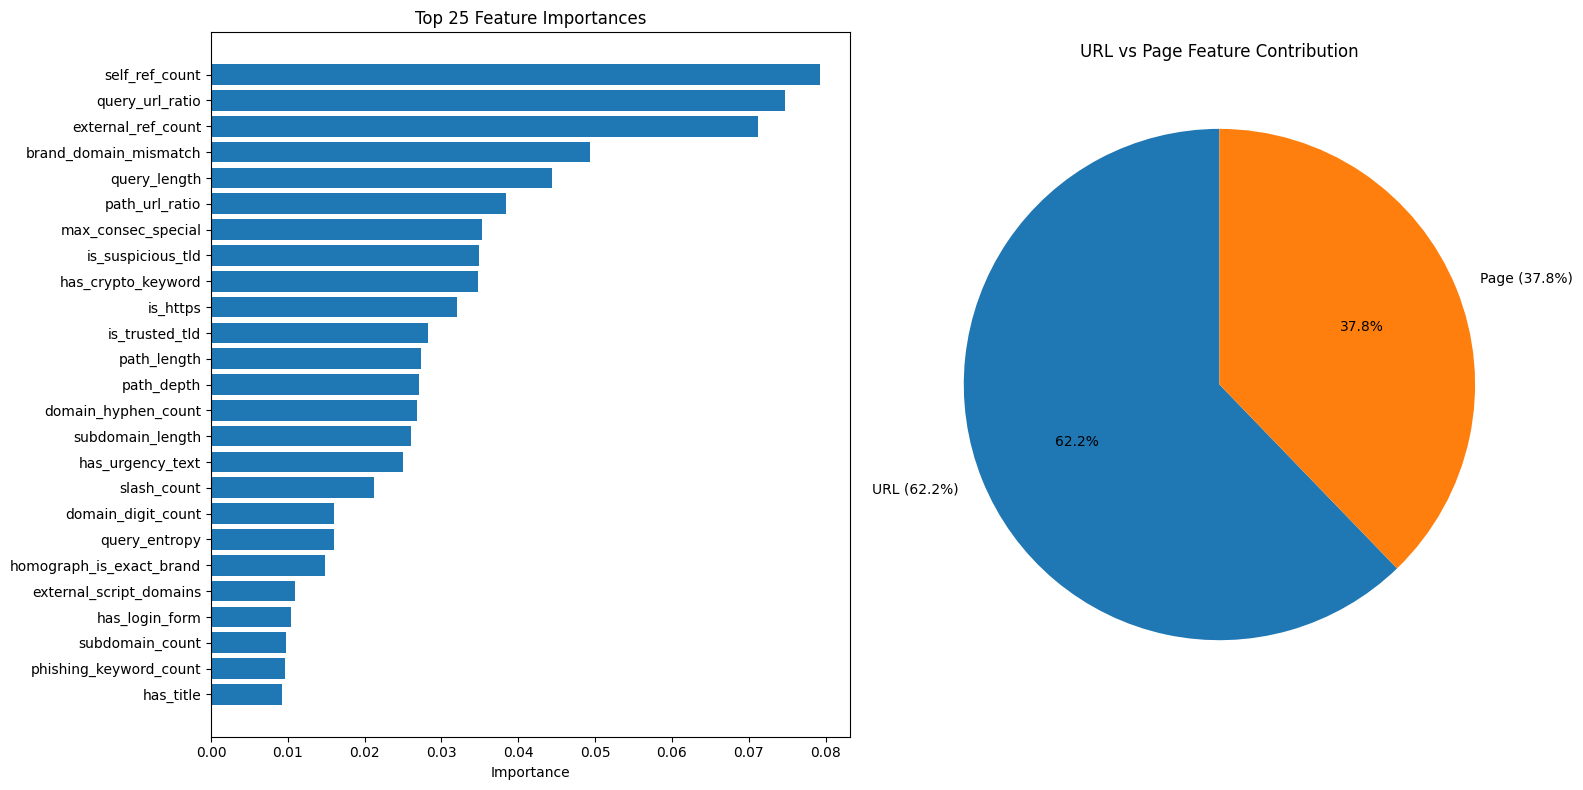

In [14]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    top = importance_df.head(25)
    axes[0].barh(range(len(top)), top['importance'].values)
    axes[0].set_yticks(range(len(top)))
    axes[0].set_yticklabels(top['feature'].values)
    axes[0].invert_yaxis()
    axes[0].set_title('Top 25 Feature Importances')
    axes[0].set_xlabel('Importance')

    axes[1].pie(
        [url_imp, page_imp],
        labels=[f'URL ({url_imp/total:.1%})', f'Page ({page_imp/total:.1%})'],
        autopct='%1.1f%%', startangle=90,
    )
    axes[1].set_title('URL vs Page Feature Contribution')

    plt.tight_layout()
    plt.show()
except ImportError:
    print('(matplotlib not available)')

## 10. Export Model

Both files must be placed in `qr-security-server/models/` for the backend to pick them up.
`feature_names.json` is the authoritative list of features the model was trained on —
the backend reads it at startup and uses it to build the inference feature vector.

In [15]:
model_dir  = SERVER_DIR / 'models'
model_dir.mkdir(exist_ok=True)

model_path = model_dir / 'xgb_model.pkl'
names_path = model_dir / 'feature_names.json'

joblib.dump(calibrated, model_path)
with open(names_path, 'w') as f:
    json.dump(FINAL_FEATURE_NAMES, f, indent=2)

print(f'Model saved:    {model_path}  ({model_path.stat().st_size / 1024:.0f} KB)')
print(f'Features saved: {names_path}  ({len(FINAL_FEATURE_NAMES)} features)')

# Round-trip check — reload and run inference on one sample.
loaded = joblib.load(model_path)
score  = loaded.predict_proba(X_test_df.iloc[:1])[0][1]
print(f'Round-trip check OK — sample P(phish) = {score:.4f}')

Model saved:    qr-security-server\models\xgb_model.pkl  (17872 KB)
Features saved: qr-security-server\models\feature_names.json  (73 features)
Round-trip check OK — sample P(phish) = 0.0055
